This program illustrates a Satellite control system with a Scade One controller

Let's start with some libraries import:

In [16]:
import control as ct
import matplotlib.pyplot as plt
import numpy as np
from scipy import linalg
from scipy.signal import lsim

We define satellite parameters to setup our plant model:

In [17]:
# Earth and orbital parameters
G = 6.6743e-11
M = 5.9722e24
mu = 3.986e14  # Earth gravitational parameter mu = G * M [m^3/s^2]
altitude = 729e3  # Orbital altitude [m]
r0 = 6.371e6 + altitude  # Orbital radius [m]
omega0 = np.sqrt(mu / r0**3)  # Orbital angular velocity [rad/s]
T_orbit = 2 * np.pi / omega0  # Orbital period [s]

# Satellite parameters
mass = 1000  # Satellite mass [kg]
drag_coeff = 2.2  # Drag coefficient
area = 2  # 10 # 10.0  # Cross-sectional area [m^2]

# Atmospheric parameters
rho = 3.1e-13  # 1.225e-12  # Atmospheric density at altitude 500 [kg/m^3]

# A33, A44
k_drag = -(rho * drag_coeff * area * r0 * omega0) / (2 * mass)

params = {
    "mu": mu,
    "r0": r0,
    "omega0": omega0,
    "T_orbit": T_orbit,
    "mass": mass,
    "k_drag": k_drag,
    "altitude": altitude,
}

Now we compute state space matrices:

In [18]:
omega0 = params["omega0"]
r0 = params["r0"]
k_drag = params["k_drag"]
mass = params["mass"]

# System matrix A (4x4)
A = np.array(
    [
        [0, 0, 1, 0],
        [0, 0, 0, 1],
        [3 * omega0**2, 0, -k_drag, -2 * r0 * omega0],
        [0, 0, 2 * omega0 / r0, -k_drag],
    ]
)
B = np.array([[0, 0], [0, 0], [1, 0], [0, 1]])

C = np.array([[1, 0, 0, 0], [0, 1, 0, 0], [0, 0, 1, 0], [0, 0, 0, 1]])
D = np.array([[0, 0], [0, 0], [0, 0], [0, 0]])

"""Print system matrices in a readable format"""
print("\nSystem Matrix A (4x4):")
for i, row in enumerate(A):
    print(f"  {row}")

print("\nControl Matrix B (4x2):")
for i, row in enumerate(B):
    print(f"  {row}")

print("\nOutput Matrix C (4x4):")
for i, row in enumerate(C):
    print(f"  {row}")

print("\nOutputControl Matrix D (4x2):")
for i, row in enumerate(D):
    print(f"  {row}")

plant = ct.ss(A, B, C, D);


System Matrix A (4x4):
  [0. 0. 1. 0.]
  [0. 0. 0. 1.]
  [ 3.34105406e-06  0.00000000e+00  5.11003468e-12 -1.49854389e+04]
  [0.00000000e+00 0.00000000e+00 2.97271155e-10 5.11003468e-12]

Control Matrix B (4x2):
  [0 0]
  [0 0]
  [1 0]
  [0 1]

Output Matrix C (4x4):
  [1 0 0 0]
  [0 1 0 0]
  [0 0 1 0]
  [0 0 0 1]

OutputControl Matrix D (4x2):
  [0 0]
  [0 0]
  [0 0]
  [0 0]


Now let's compute LQ controler (K matrix) by state feedback with some arbitrary choice of weights Q and R:

In [19]:
# Form Q and R matrices
Q = np.diag(np.asarray([1, 1, 1, 1]))
R = np.diag(np.asarray([10, 10]))

# Solve Riccati equation
P = linalg.solve_continuous_are(A, B, Q, R)
K = np.linalg.inv(R) @ B.T @ P

"""Print controller matrices"""
print("\nLQR Gain Matrix K (2x4):")
for i, row in enumerate(K):
    print(f"  {row}")


LQR Gain Matrix K (2x4):
  [ 0.00207535  0.31622098  0.00211798 -0.32271692]
  [-3.16220978e-01  2.07200806e-03 -3.22716923e-01  9.83468834e+01]


Now we put the plant with LQ controller (K matrix) in a closed-loop form:

In [20]:
Acl = A - B @ K @ C
Bcl = B @ K
Dcl = np.array([[0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]])

closed_loop = ct.ss(Acl, Bcl, C, Dcl);

We setup timeline, inital conditions and input reference signals to run the simulation:

In [21]:
dt = 0.01
t = np.linspace(0, 20, 2000)

# Initial condition
mu = 3.986e14  # Earth gravitational parameter mu = G * M [m^3/s^2]
altitude = 729e3  # Orbital altitude [m]
r0 = 6.371e6 + altitude  # Orbital radius [m]
omega0 = np.sqrt(mu / r0**3)  # Orbital angular velocity [rad/s]
theta = t * omega0

# Reference input
r = np.zeros((len(t), 4))
r[:, 0] = r0  # constant on input 1
r[:, 1] = theta
r[:, 2] = 0
r[:, 3] = omega0

# Step function
start1 = 100 * dt  # starting time (cycles)
amplitude1 = 1000
start2 = 1000 * dt
amplitude2 = 500
offset = r0
dist1 = offset + amplitude1 * (t >= start1)
dist2 = amplitude2 * (t >= start2)
dist_x = np.zeros((len(t), 4))
r[:, 0] = dist1 + dist2

x0 = np.array([r0, 0, 0, omega0]);  # initial state

Now we can run the closed loop system and check performances for reference tracking:

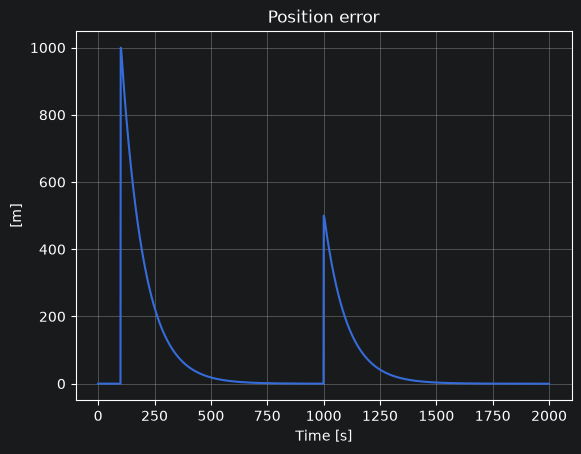

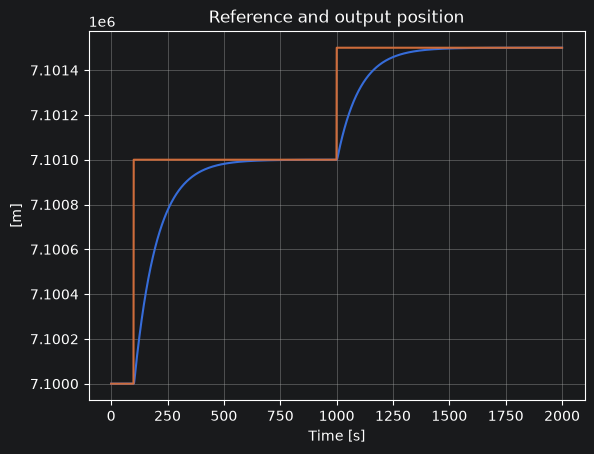

In [22]:
t, y, x = lsim((Acl, Bcl, C, Dcl), U=r, T=t, X0=x0)
error_ct = r - y
t_scade_one = t / dt

plt.figure(1)
plt.plot(t_scade_one, error_ct[:, 0])
plt.title("Position error")
plt.xlabel("Time [s]")
plt.ylabel("[m]")
plt.grid()
plt.show()

plt.figure(2)
plt.plot(t_scade_one, y[:, 0])
plt.plot(t_scade_one, r[:, 0])
plt.title("Reference and output position")
plt.xlabel("Time [s]")
plt.ylabel("[m]")
plt.grid()
plt.show()

Now we will do the same simulation, but using the controller exported from Scade One. First we'll create a Python Proxy for the Scade One controller, using the Python wrapper service.

In [24]:
from pathlib import Path

from ansys.scadeone.core import ScadeOne
from ansys.scadeone.core.svc.pywrapper import PythonWrapper

# Update if needed according to your installation
s_one_install = Path(r"C:\Program Files\ANSYS Inc\v261\Scade One")
satellite_project = (Path.cwd() / "SatelliteScadeOne") / "Satellite.sproj"
print(satellite_project)
# Job name
job_name = "CodeGenerationJobController"

# Wrapper name
out_name = "satellite_control_wrapper"

# Wrapper target directory
target_dir = Path.cwd()

app = ScadeOne(install_dir=s_one_install)
prj = app.load_project(satellite_project)

# Load and run the Code Generation job
prj.load_jobs()

print("Available jobs:")
for job in prj.jobs:
    print("-", job.name)

cg_job = prj.get_job(job_name)
result = cg_job.run()
assert result.code == 0

# Generate the Python wrapper
gen = PythonWrapper(project=prj, job=job_name, output=out_name, target_dir=target_dir)
gen.generate()

C:\AnsysDev\Git\Github\scadeone-examples\scadeone-examples\models\2026-XX-satellite-controller\SatelliteScadeOne\Satellite.sproj
Available jobs:
- CodeGenerationJobController
- SimulationJobSatelliteWithControl


PermissionError: [WinError 5] Access is denied: 'C:\\AnsysDev\\Git\\Github\\scadeone-examples\\scadeone-examples\\models\\2026-XX-satellite-controller\\satellite_control_wrapper\\satellite_control_wrapper.dll'

Once the script has been executed, a generated folder is available in the current location containing the wrapped code. The next step is to import it: 

In [ ]:
from satellite_control_wrapper import satellite_control_wrapper

# Create an instance of a controller main operator
satellite_controller = satellite_control_wrapper.LQController_Control()

The current continuous-time satellite model is discretized to enable simulation:

In [ ]:
plant_d = ct.c2d(plant, dt)
A = plant_d.A
B = plant_d.B
C = plant_d.C
D = plant_d.D

Next, some storage variables are prepared to perform the simulation:

In [ ]:
# Initial state
x_dt = x0.copy()

# Storage
y_hist = np.zeros((len(t), 4))
u_hist = np.zeros((len(t), 2))
error_hist = np.zeros((len(t), 4))

Once this is done, the discrete-time system output can be computed:

In [ ]:
for i, timer in enumerate(t):
    # --- Plant output ---

    y_dt = C @ x_dt
    y_hist[i, :] = y_dt

    # --- Error ---
    error = r[i, :] - y_dt
    error_hist[i, :] = error  # store

    # --- Controller ---
    input1 = r[i, :]
    input2 = y_hist[i, :]
    # --- Fill inputs (ctypes arrays) ---
    for k in range(4):
        satellite_controller.inputs._yRef[k] = float(input1[k])
        satellite_controller.inputs._y[k] = float(input2[k])

    # --- Call the SCADE operator ---
    satellite_controller.cycle_fct(
        satellite_controller.inputs._yRef,
        satellite_controller.inputs._y,
        satellite_controller.outputs._u,
    )

    # --- Extract outputs properly ---
    u = np.array([satellite_controller.outputs._u[i] for i in range(2)])
    u = np.array(u)

    # store results
    u_hist[i, :] = u

    # --- Plant update ---
    x_dt = A @ x_dt + B @ u

plt.figure(1)
plt.plot(t_scade_one, error_hist[:, 0])
plt.title("Position error")
plt.xlabel("Time [s]")
plt.ylabel("[m]")
plt.grid()
plt.show()

plt.figure(2)
plt.plot(t_scade_one, y_hist[:, 0])
plt.plot(t_scade_one, r[:, 0])
plt.title("Reference and output position")
plt.xlabel("Time [s]")
plt.ylabel("[m]")
plt.grid()
plt.show()

The curves obtained from the continuous-time and discrete-time simulations are very similar. The difference in tracking errors is then plotted:

In [ ]:
plt.figure(1)
plt.plot(t_scade_one, error_hist[:, 0] - error_ct[:, 0])
plt.title("Position error difference")
plt.xlabel("Time [s]")
plt.ylabel("[m]")
plt.grid()
plt.show()